# Agricultural Human-Detection — 3D LiDAR Benchmark
### AGHRI dataset: PointPillars vs SECOND, scratch vs KITTI-pretrained

This notebook analyses all MMDetection3D results on the **AGHRI** LiDAR dataset (pedestrian detection, single class: `person`).

**Primary metrics** — IoU thresholds 0.25 and 0.50 are used throughout, because persons are
small objects in 3D space and IoU 0.75 is excessively strict for this class.

**Two model families** are compared:
- **PointPillars** — pillar-based, fast inference
- **SECOND** — voxel-based sparse convolution, higher accuracy at the cost of speed

**Two training regimes** per family:
- **Scratch** — trained from scratch on AGHRI only
- **KITTI-pretrained** — pre-trained on KITTI pedestrian data, then fine-tuned on AGHRI

A brief **KITTI reference section** provides context for how models perform on a road-domain
benchmark, but cross-dataset transfer analysis is out of scope for this notebook.

In [1]:
import json
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

# ── Colour palettes ────────────────────────────────────────────────────────────
MODEL_PALETTE = {
    'PointPillars (scratch)':         '#E07B39',  # orange
    'SECOND (scratch)':               '#C0392B',  # red
    'PointPillars (KITTI-pretrained)': '#2980B9',  # blue
    'SECOND (KITTI-pretrained)':       '#1A5276',  # dark blue
}
ARCH_PALETTE = {
    'PointPillars': '#E07B39',
    'SECOND':       '#C0392B',
}
REGIME_PALETTE = {
    'Scratch':           '#E07B39',
    'KITTI-pretrained':  '#2980B9',
}

# ── Locate summary files ───────────────────────────────────────────────────────
SUMMARY_DIR_CANDIDATES = [
    Path('../reports/benchmarks/summary/mmdetection3d'),
    Path('3d-detection/reports/benchmarks/summary/mmdetection3d'),
    Path('reports/benchmarks/summary/mmdetection3d'),
]
SUMMARY_DIR = next((p for p in SUMMARY_DIR_CANDIDATES if p.exists()), SUMMARY_DIR_CANDIDATES[0])
print(f'Summary directory: {SUMMARY_DIR.resolve()}')

Summary directory: D:\AOC\agri-human-dataset-benchmark\3d-detection\reports\benchmarks\summary\mmdetection3d


In [2]:
# ── Load all JSON summary files ────────────────────────────────────────────────
json_files = sorted(SUMMARY_DIR.glob('summary_mmdetection3d_*.json'))
if not json_files:
    raise FileNotFoundError(f'No JSON files found under {SUMMARY_DIR.resolve()}')

MODEL_META = {
    'second_aghri':                       {'label': 'SECOND (scratch)',               'arch': 'SECOND',        'regime': 'Scratch',          'eval_dataset': 'AGHRI'},
    'pointpillars_aghri':                 {'label': 'PointPillars (scratch)',          'arch': 'PointPillars',  'regime': 'Scratch',          'eval_dataset': 'AGHRI'},
    'second_kitti_pretrained_aghri':      {'label': 'SECOND (KITTI-pretrained)',       'arch': 'SECOND',        'regime': 'KITTI-pretrained', 'eval_dataset': 'AGHRI'},
    'pointpillars_kitti_pretrained_aghri':{'label': 'PointPillars (KITTI-pretrained)', 'arch': 'PointPillars',  'regime': 'KITTI-pretrained', 'eval_dataset': 'AGHRI'},
    'second_kitti':                       {'label': 'SECOND',                          'arch': 'SECOND',        'regime': 'In-domain',        'eval_dataset': 'KITTI'},
    'pointpillars_kitti':                 {'label': 'PointPillars',                    'arch': 'PointPillars',  'regime': 'In-domain',        'eval_dataset': 'KITTI'},
}

rows = []
for jf in json_files:
    data = json.loads(jf.read_text())
    for rec in data:
        model_key = rec['model']
        meta = MODEL_META.get(model_key, {})
        rows.append({**rec, **meta, 'source_file': jf.name})

bench = pd.DataFrame(rows)

# Cast numerics
num_cols = [
    'inf_time_per_frame_ms', 'train_time_sec',
    'bev_ap_0.25', 'bev_ap_0.50', 'bev_ap_0.75', 'bev_ap_mean',
    '3d_ap_0.25',  '3d_ap_0.50',  '3d_ap_0.75',  '3d_ap_mean',
    'bev_precision_0.25', 'bev_precision_0.50',
    '3d_precision_0.25',  '3d_precision_0.50',
    'bev_recall_0.25',    'bev_recall_0.50',
    '3d_recall_0.25',     '3d_recall_0.50',
    'bev_f1_0.25',        'bev_f1_0.50',
    '3d_f1_0.25',         '3d_f1_0.50',
    'precision', 'recall', 'f1', 'epochs',
]
for col in num_cols:
    if col in bench.columns:
        bench[col] = pd.to_numeric(bench[col], errors='coerce')

aghri = bench[bench['eval_dataset'] == 'AGHRI'].copy()
kitti = bench[bench['eval_dataset'] == 'KITTI'].copy()

print(f'Loaded {len(bench)} model-run rows: {len(aghri)} AGHRI, {len(kitti)} KITTI')
bench[['label', 'eval_dataset', 'regime', 'bev_ap_0.25', '3d_ap_0.25', 'bev_ap_0.50', '3d_ap_0.50', 'inf_time_per_frame_ms']]

Loaded 6 model-run rows: 4 AGHRI, 2 KITTI


,label,eval_dataset,regime,bev_ap_0.25,3d_ap_0.25,bev_ap_0.50,3d_ap_0.50,inf_time_per_frame_ms
0,PointPillars (scratch),AGHRI,Scratch,0.127114,0.125295,0.095320,0.055582,12.159
1,SECOND (scratch),AGHRI,Scratch,0.445916,0.388043,0.160944,0.070192,22.844
2,PointPillars,KITTI,In-domain,0.205425,0.205057,0.110381,0.073406,16.142
3,PointPillars (KITTI-pretrained),AGHRI,KITTI-pretrained,0.396805,0.395117,0.347197,0.270448,12.739
4,SECOND (KITTI-pretrained),AGHRI,KITTI-pretrained,0.416124,0.397155,0.272382,0.182975,23.520
5,SECOND,KITTI,In-domain,0.060741,0.059999,0.034947,0.028377,26.294


In [3]:
# ── Shared plot helpers ────────────────────────────────────────────────────────

def annotate_hbars(ax, fmt: str = '{:.3f}') -> None:
    for container in ax.containers:
        for bar in container:
            w = bar.get_width()
            if w > 0:
                ax.text(w + 0.003, bar.get_y() + bar.get_height() / 2,
                        fmt.format(w), va='center', fontsize=9, fontweight='bold')


def annotate_vbars(ax, fmt: str = '{:.3f}') -> None:
    for container in ax.containers:
        for bar in container:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.004,
                        fmt.format(h), ha='center', va='bottom', fontsize=9, fontweight='bold')

---
## Section 1 — AGHRI Benchmark: Summary Table
> *All models evaluated on the AGHRI LiDAR pedestrian test set.*

BEV AP and 3D AP at IoU thresholds **0.25** and **0.50** are the primary metrics.
Humans are small objects in 3D point clouds, so 0.75 IoU is excluded as overly penalising.
Inference time is measured on a fixed single-frame input (100 iterations, 20 warmup).

In [4]:
# ── AGHRI summary table ────────────────────────────────────────────────────────
TABLE_COLS = [
    'label', 'arch', 'regime', 'epochs',
    'bev_ap_0.25', '3d_ap_0.25',
    'bev_ap_0.50', '3d_ap_0.50',
    'bev_f1_0.25', '3d_f1_0.25',
    'inf_time_per_frame_ms',
]
existing = [c for c in TABLE_COLS if c in aghri.columns]
tbl = (
    aghri[existing]
    .rename(columns={
        'label':                'Model',
        'arch':                 'Architecture',
        'regime':               'Training regime',
        'epochs':               'Epochs',
        'bev_ap_0.25':          'BEV AP @0.25',
        '3d_ap_0.25':           '3D AP @0.25',
        'bev_ap_0.50':          'BEV AP @0.50',
        '3d_ap_0.50':           '3D AP @0.50',
        'bev_f1_0.25':          'BEV F1 @0.25',
        '3d_f1_0.25':           '3D F1 @0.25',
        'inf_time_per_frame_ms':'ms / frame',
    })
    .sort_values('3D AP @0.25', ascending=False)
    .reset_index(drop=True)
)

fmt_map = {c: '{:.3f}' for c in tbl.columns if tbl[c].dtype == float}
fmt_map['ms / frame'] = '{:.1f}'
fmt_map['Epochs'] = '{:.0f}'

def highlight_pretrained(row):
    bg = '#E8F4FD' if 'KITTI-pretrained' in str(row.get('Training regime', '')) else ''
    return [f'background-color: {bg}'] * len(row)

display(Markdown("### AGHRI test-set results — all models (sorted by 3D AP @0.25)"))
display(
    tbl.style
    .apply(highlight_pretrained, axis=1)
    .format(fmt_map, na_rep='—')
    .set_caption('Blue rows = KITTI-pretrained models. '
                 'Primary metrics: BEV AP @0.25 and 3D AP @0.25 (small-object IoU).')
)

### AGHRI test-set results — all models (sorted by 3D AP @0.25)

,Model,Architecture,Training regime,Epochs,BEV AP @0.25,3D AP @0.25,BEV AP @0.50,3D AP @0.50,BEV F1 @0.25,3D F1 @0.25,ms / frame
0,SECOND (KITTI-pretrained),SECOND,KITTI-pretrained,40,0.416,0.397,0.272,0.183,0.571,0.551,23.5
1,PointPillars (KITTI-pretrained),PointPillars,KITTI-pretrained,80,0.397,0.395,0.347,0.270,0.532,0.530,12.7
2,SECOND (scratch),SECOND,Scratch,40,0.446,0.388,0.161,0.070,0.604,0.543,22.8
3,PointPillars (scratch),PointPillars,Scratch,4,0.127,0.125,0.095,0.056,0.191,0.187,12.2


---
## Section 2 — BEV AP & 3D AP at IoU 0.25 and 0.50
> *Horizontal bar charts: each model-family at two IoU thresholds.*

Because pedestrians are small objects, **IoU 0.25** is a more informative primary threshold;
**IoU 0.50** shows how tightly localised the predictions are in 3D space.

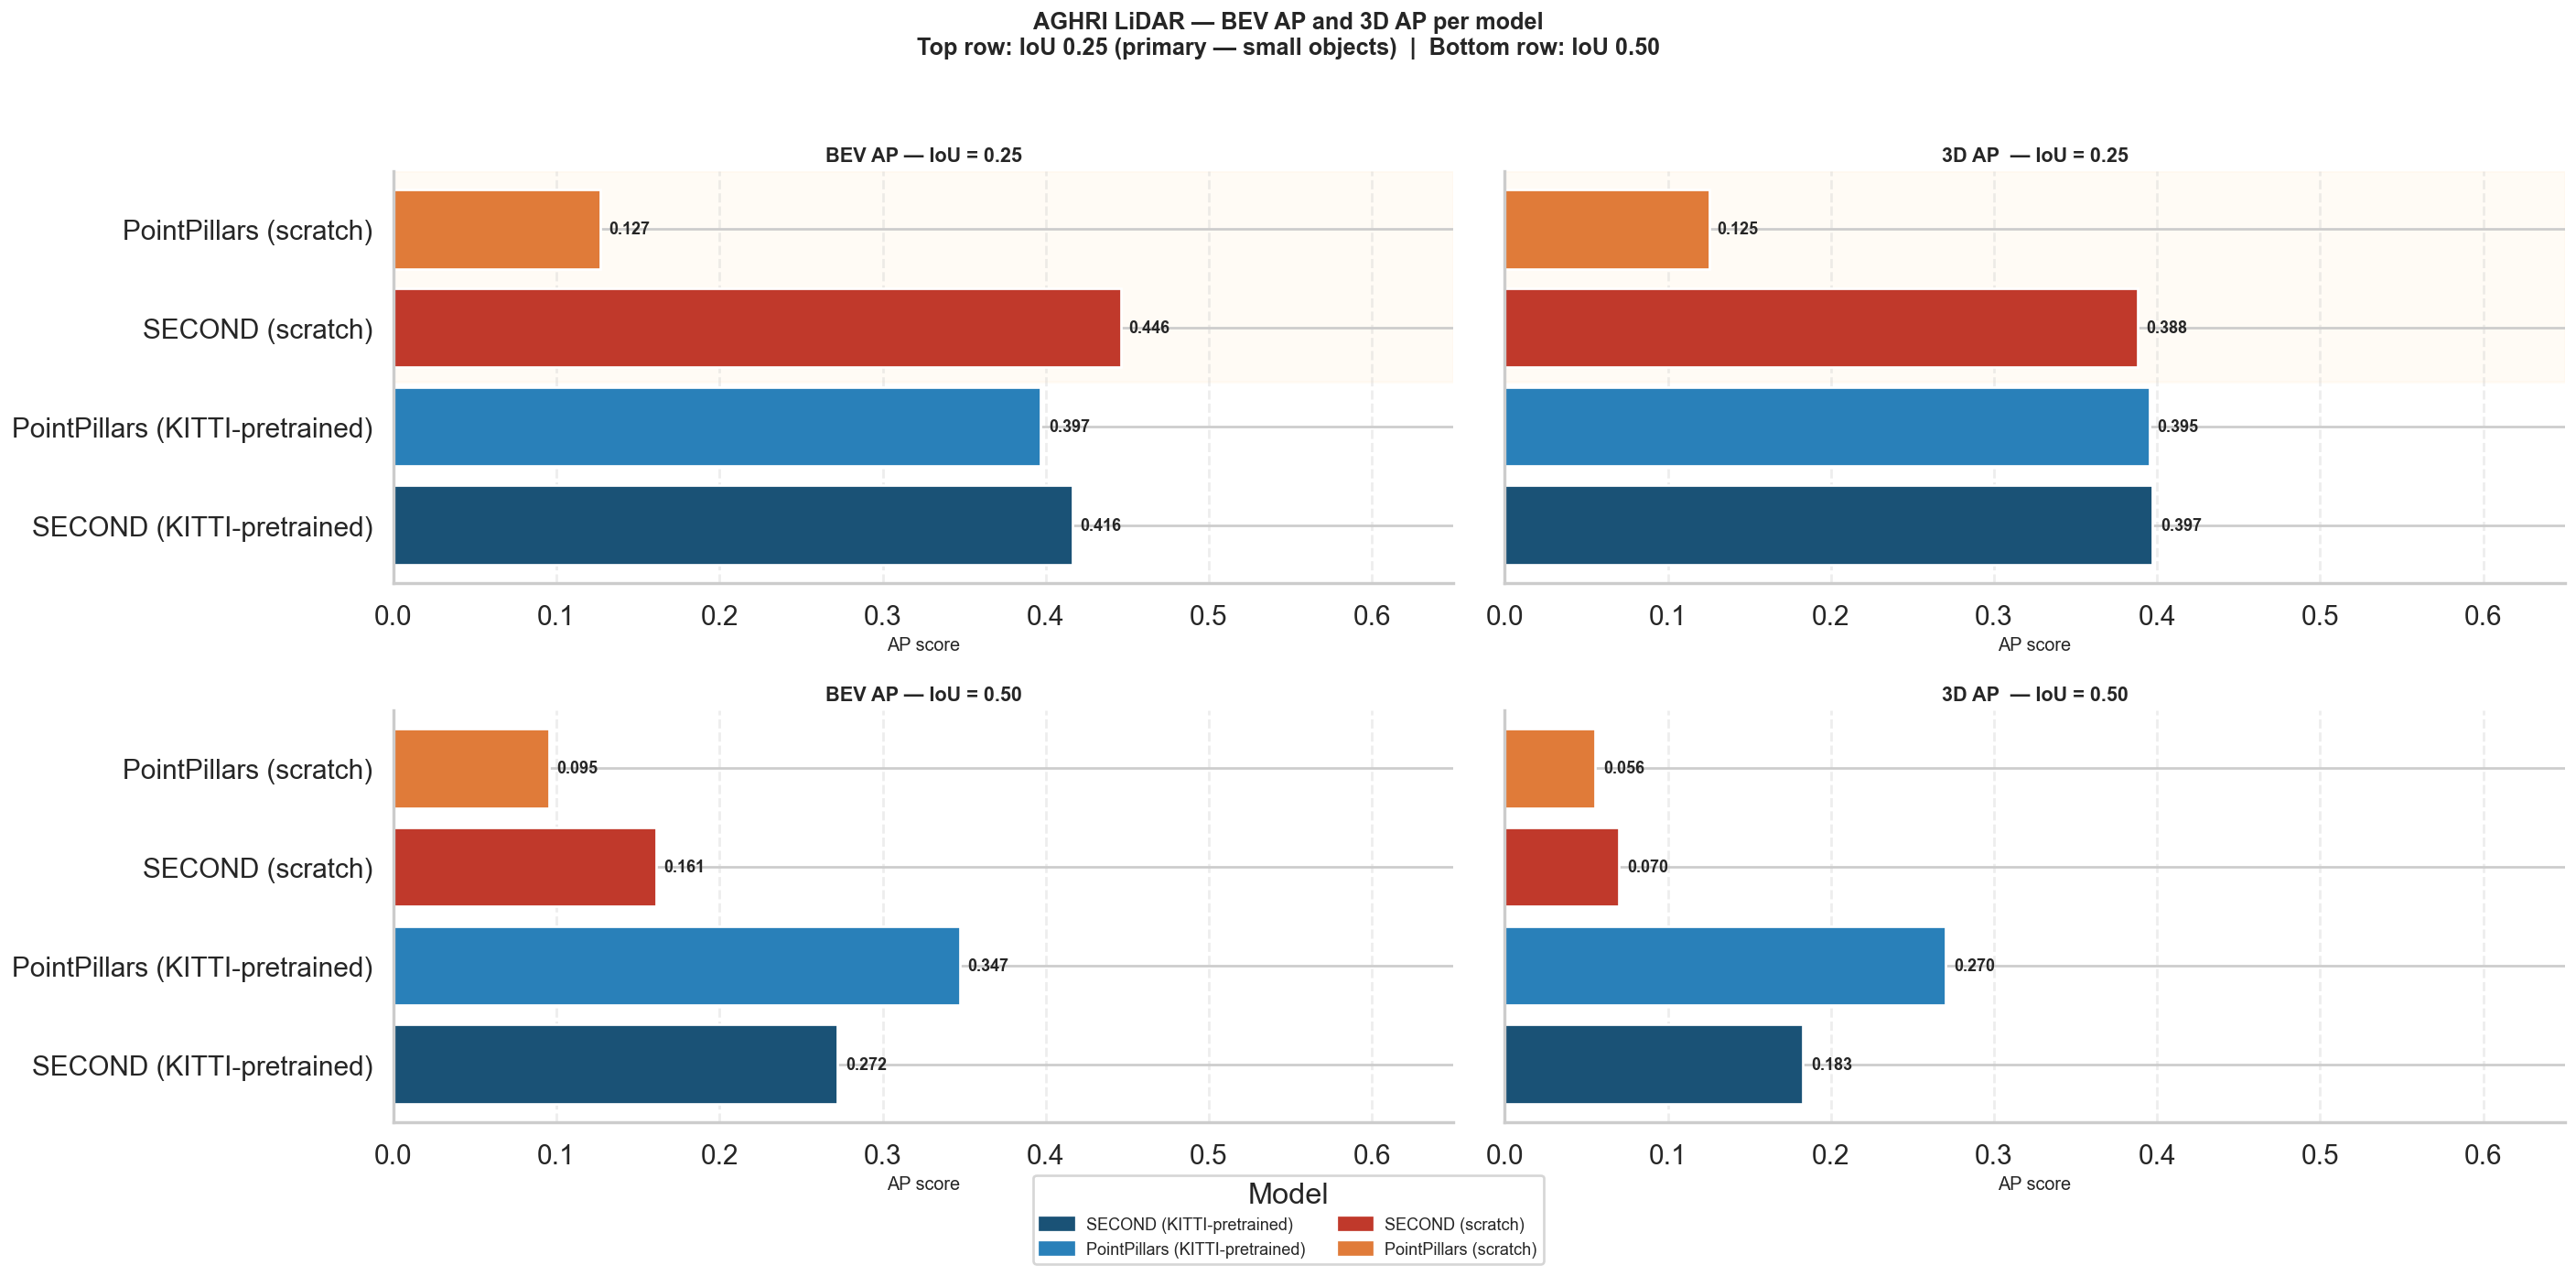

In [5]:
# ── Figure 1: BEV AP and 3D AP at IoU 0.25 and 0.50 ──────────────────────────
MODEL_ORDER = [
    'SECOND (KITTI-pretrained)',
    'PointPillars (KITTI-pretrained)',
    'SECOND (scratch)',
    'PointPillars (scratch)',
]
MODEL_ORDER = [m for m in MODEL_ORDER if m in aghri['label'].values]

palette = {m: MODEL_PALETTE.get(m, '#AAB7B8') for m in MODEL_ORDER}

iou_pairs = [
    ('bev_ap_0.25', '3d_ap_0.25', 'IoU = 0.25'),
    ('bev_ap_0.50', '3d_ap_0.50', 'IoU = 0.50'),
]

fig, axes = plt.subplots(2, 2, figsize=(22, 10), sharey='row')

for row_idx, (bev_col, d3_col, iou_label) in enumerate(iou_pairs):
    for col_idx, (metric_col, metric_title) in enumerate([
        (bev_col, f'BEV AP — {iou_label}'),
        (d3_col,  f'3D AP  — {iou_label}'),
    ]):
        ax = axes[row_idx][col_idx]
        data_plot = (
            aghri.set_index('label')
            .reindex(MODEL_ORDER)[[metric_col]]
            .reset_index()
        )
        colors = [palette.get(m, '#AAB7B8') for m in data_plot['label']]
        bars = ax.barh(data_plot['label'], data_plot[metric_col], color=colors, edgecolor='white')
        for bar, val in zip(bars, data_plot[metric_col]):
            if pd.notna(val) and val > 0:
                ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                        f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
        ax.set_xlabel('AP score', fontsize=11)
        ax.set_xlim(0, 0.65)
        ax.set_title(metric_title, fontsize=12, fontweight='bold')
        ax.grid(axis='x', linestyle='--', alpha=0.35)
        if row_idx == 0:
            ax.axvspan(0, 0.65, ymin=0.49, ymax=1.0, color='#FFF3E0', zorder=0, alpha=0.3)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
fig.legend(handles=legend_patches, title='Model', loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.04), fontsize=10, frameon=True)
fig.suptitle('AGHRI LiDAR — BEV AP and 3D AP per model\n'
             'Top row: IoU 0.25 (primary — small objects)  |  Bottom row: IoU 0.50',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

---
## Section 3 — Pretraining Effect: Scratch vs KITTI-Pretrained
> *How much does KITTI pretraining help each model family on AGHRI?*

This section quantifies the delta between training from scratch and using a KITTI-pretrained
backbone at both IoU thresholds.

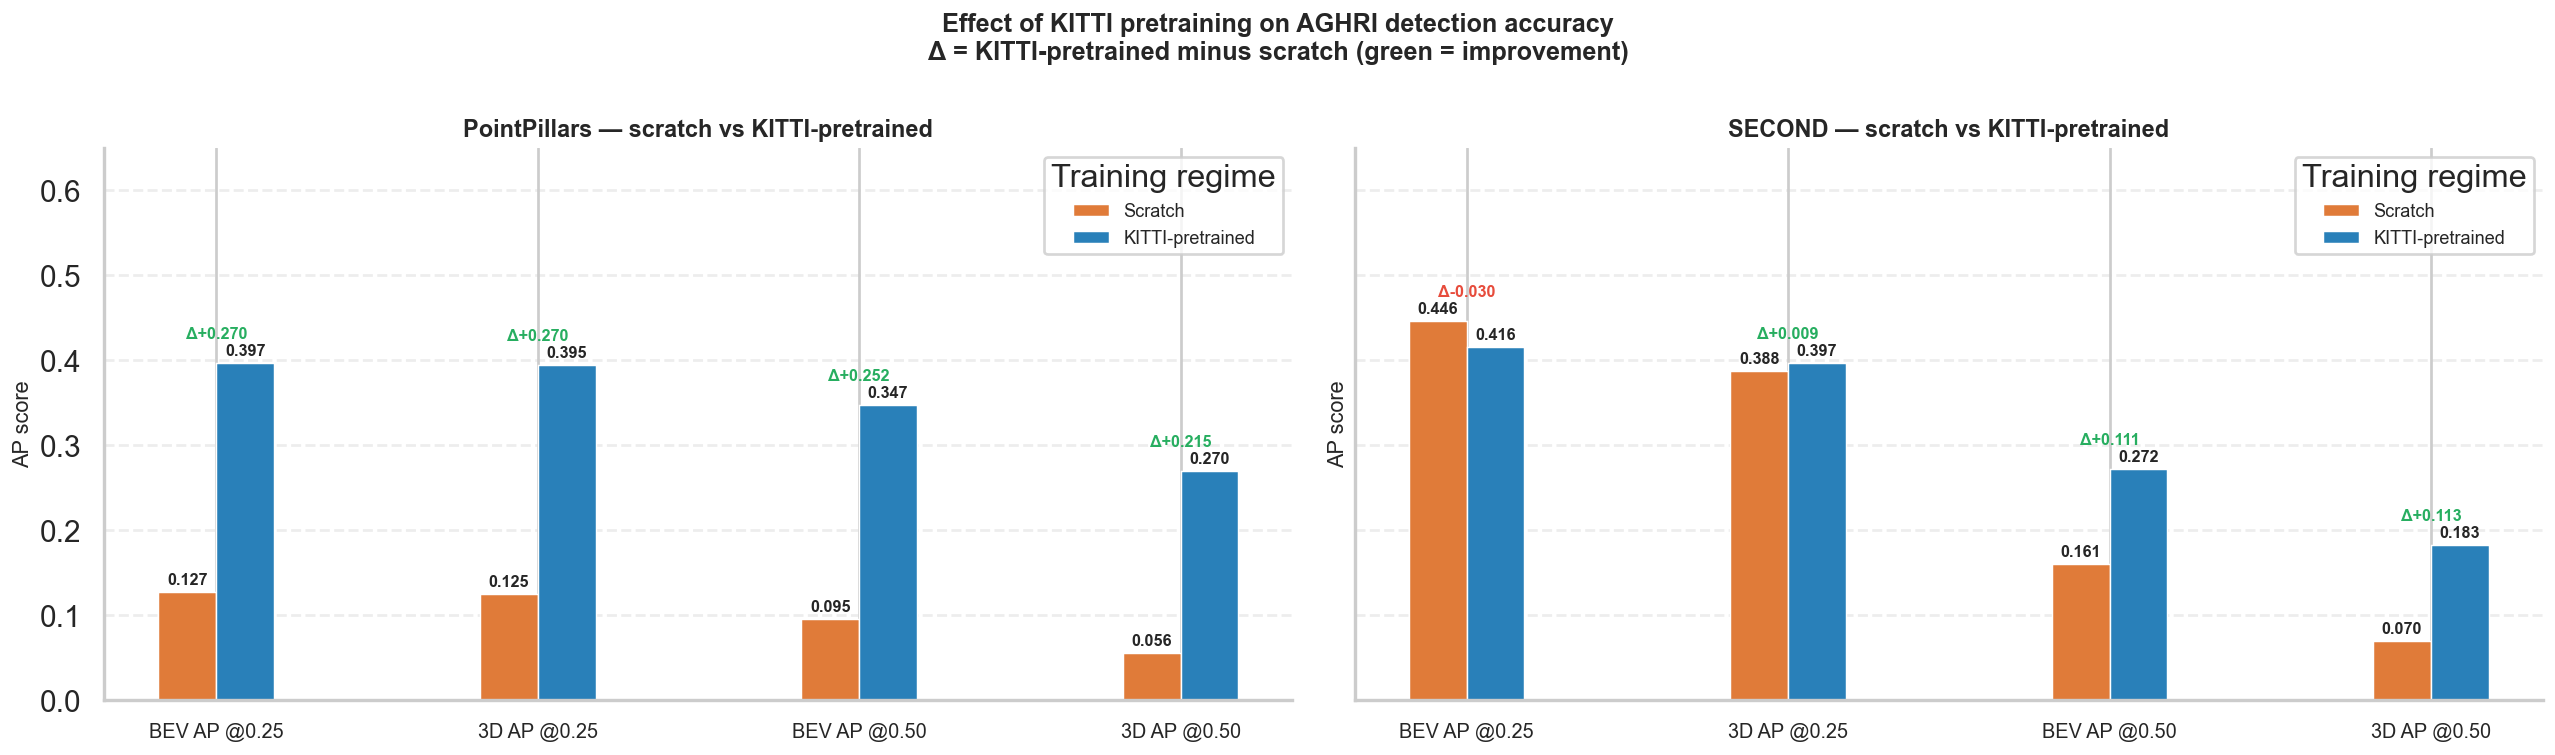

In [6]:
# ── Figure 2: Grouped bar — scratch vs pretrained per architecture ─────────────
METRICS = [
    ('bev_ap_0.25', 'BEV AP @0.25'),
    ('3d_ap_0.25',  '3D AP @0.25'),
    ('bev_ap_0.50', 'BEV AP @0.50'),
    ('3d_ap_0.50',  '3D AP @0.50'),
]

archs   = ['PointPillars', 'SECOND']
regimes = ['Scratch', 'KITTI-pretrained']

x = np.arange(len(METRICS))
width = 0.18

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax_idx, arch in enumerate(archs):
    ax = axes[ax_idx]
    arch_data = aghri[aghri['arch'] == arch].set_index('regime')

    for r_idx, regime in enumerate(regimes):
        if regime not in arch_data.index:
            continue
        vals = [float(arch_data.loc[regime, col]) if col in arch_data.columns else np.nan
                for col, _ in METRICS]
        offset = (r_idx - 0.5) * width
        bars = ax.bar(x + offset, vals, width,
                      label=regime,
                      color=REGIME_PALETTE[regime],
                      edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, vals):
            if np.isfinite(val) and val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # ── delta annotations ─────────────────────────────────────────────────────
    if 'Scratch' in arch_data.index and 'KITTI-pretrained' in arch_data.index:
        for m_idx, (col, _) in enumerate(METRICS):
            sc  = float(arch_data.loc['Scratch',           col])
            pt  = float(arch_data.loc['KITTI-pretrained',  col])
            delta = pt - sc
            colour = '#27AE60' if delta > 0 else '#E74C3C'
            ax.text(m_idx, max(sc, pt) + 0.025, f'Δ{delta:+.3f}',
                    ha='center', va='bottom', fontsize=9, color=colour, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([label for _, label in METRICS], fontsize=11)
    ax.set_ylim(0, 0.65)
    ax.set_ylabel('AP score', fontsize=12)
    ax.set_title(f'{arch} — scratch vs KITTI-pretrained', fontsize=13, fontweight='bold')
    ax.legend(title='Training regime', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

fig.suptitle('Effect of KITTI pretraining on AGHRI detection accuracy\n'
             'Δ = KITTI-pretrained minus scratch (green = improvement)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ── Pretraining delta table ────────────────────────────────────────────────────
delta_rows = []
for arch in archs:
    sub = aghri[aghri['arch'] == arch].set_index('regime')
    if 'Scratch' not in sub.index or 'KITTI-pretrained' not in sub.index:
        continue
    row = {'Architecture': arch}
    for col, label in METRICS:
        sc = float(sub.loc['Scratch',          col])
        pt = float(sub.loc['KITTI-pretrained', col])
        row[f'{label} (scratch)']     = sc
        row[f'{label} (pretrained)']  = pt
        row[f'Δ {label}']             = pt - sc
    delta_rows.append(row)

delta_df = pd.DataFrame(delta_rows).set_index('Architecture')
delta_cols = [c for c in delta_df.columns if c.startswith('Δ')]

display(Markdown("### Pretraining delta: KITTI-pretrained minus scratch"))
display(
    delta_df.style
    .format('{:.3f}')
    .background_gradient(cmap='RdYlGn', subset=delta_cols, vmin=-0.1, vmax=0.25)
    .set_caption('Green = pretraining improves accuracy. '
                 'Δ computed as (KITTI-pretrained) − (scratch).')
)

### Pretraining delta: KITTI-pretrained minus scratch

,BEV AP @0.25 (scratch),BEV AP @0.25 (pretrained),Δ BEV AP @0.25,3D AP @0.25 (scratch),3D AP @0.25 (pretrained),Δ 3D AP @0.25,BEV AP @0.50 (scratch),BEV AP @0.50 (pretrained),Δ BEV AP @0.50,3D AP @0.50 (scratch),3D AP @0.50 (pretrained),Δ 3D AP @0.50
Architecture,,,,,,,,,,,,
PointPillars,0.127,0.397,0.270,0.125,0.395,0.270,0.095,0.347,0.252,0.056,0.270,0.215
SECOND,0.446,0.416,-0.030,0.388,0.397,0.009,0.161,0.272,0.111,0.070,0.183,0.113


---
## Section 4 — Inference Speed
> *Measured on a fixed single-frame input (100 iterations, 20 warmup runs).*

LiDAR-based 3D detection must often run near real-time. Inference time is reported in
**milliseconds per frame** (lower = faster).

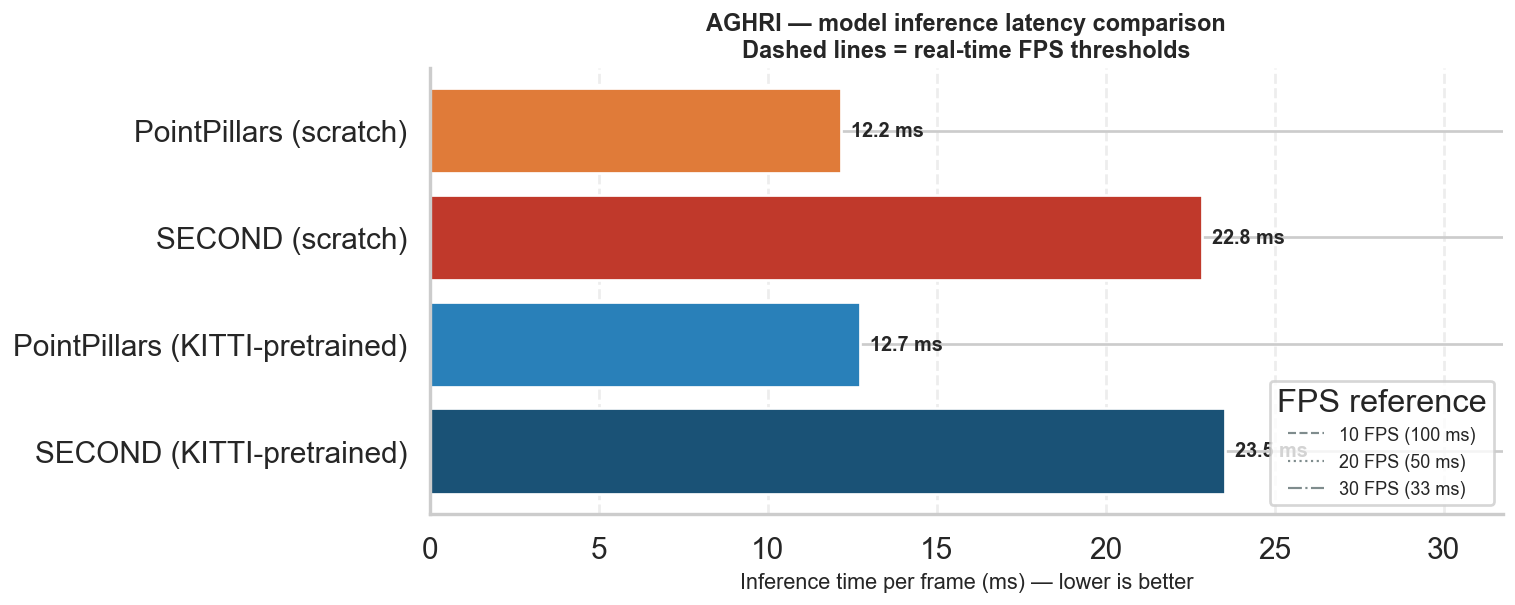

Fastest: PointPillars (scratch) — 12.2 ms (82.2 FPS)
Slowest: SECOND (KITTI-pretrained) — 23.5 ms (42.5 FPS)
Speed ratio (slowest / fastest): 1.9×


In [8]:
# ── Figure 3: Inference speed ──────────────────────────────────────────────────
speed_data = (
    aghri.set_index('label')
    .reindex(MODEL_ORDER)[['inf_time_per_frame_ms', 'arch', 'regime']]
    .reset_index()
)

colors = [MODEL_PALETTE.get(m, '#AAB7B8') for m in speed_data['label']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(speed_data['label'], speed_data['inf_time_per_frame_ms'],
               color=colors, edgecolor='white')
for bar, val in zip(bars, speed_data['inf_time_per_frame_ms']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} ms', va='center', fontsize=11, fontweight='bold')

# Real-time reference lines
for fps, style in [(10, '--'), (20, ':'), (30, '-.')]: 
    ms = 1000 / fps
    ax.axvline(ms, color='#7F8C8D', linestyle=style, linewidth=1.2,
               label=f'{fps} FPS ({ms:.0f} ms)')

ax.set_xlabel('Inference time per frame (ms) — lower is better', fontsize=12)
ax.set_title('AGHRI — model inference latency comparison\n'
             'Dashed lines = real-time FPS thresholds', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(speed_data['inf_time_per_frame_ms']) * 1.35)
ax.legend(title='FPS reference', fontsize=10, loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

# Speed ratio summary
min_ms = speed_data['inf_time_per_frame_ms'].min()
max_ms = speed_data['inf_time_per_frame_ms'].max()
fastest = speed_data.loc[speed_data['inf_time_per_frame_ms'].idxmin(), 'label']
slowest = speed_data.loc[speed_data['inf_time_per_frame_ms'].idxmax(), 'label']
print(f'Fastest: {fastest} — {min_ms:.1f} ms ({1000/min_ms:.1f} FPS)')
print(f'Slowest: {slowest} — {max_ms:.1f} ms ({1000/max_ms:.1f} FPS)')
print(f'Speed ratio (slowest / fastest): {max_ms / min_ms:.1f}×')

---
## Section 5 — Accuracy vs Speed Trade-off
> *Scatter plot: primary metric (3D AP @0.25) vs inference time.*

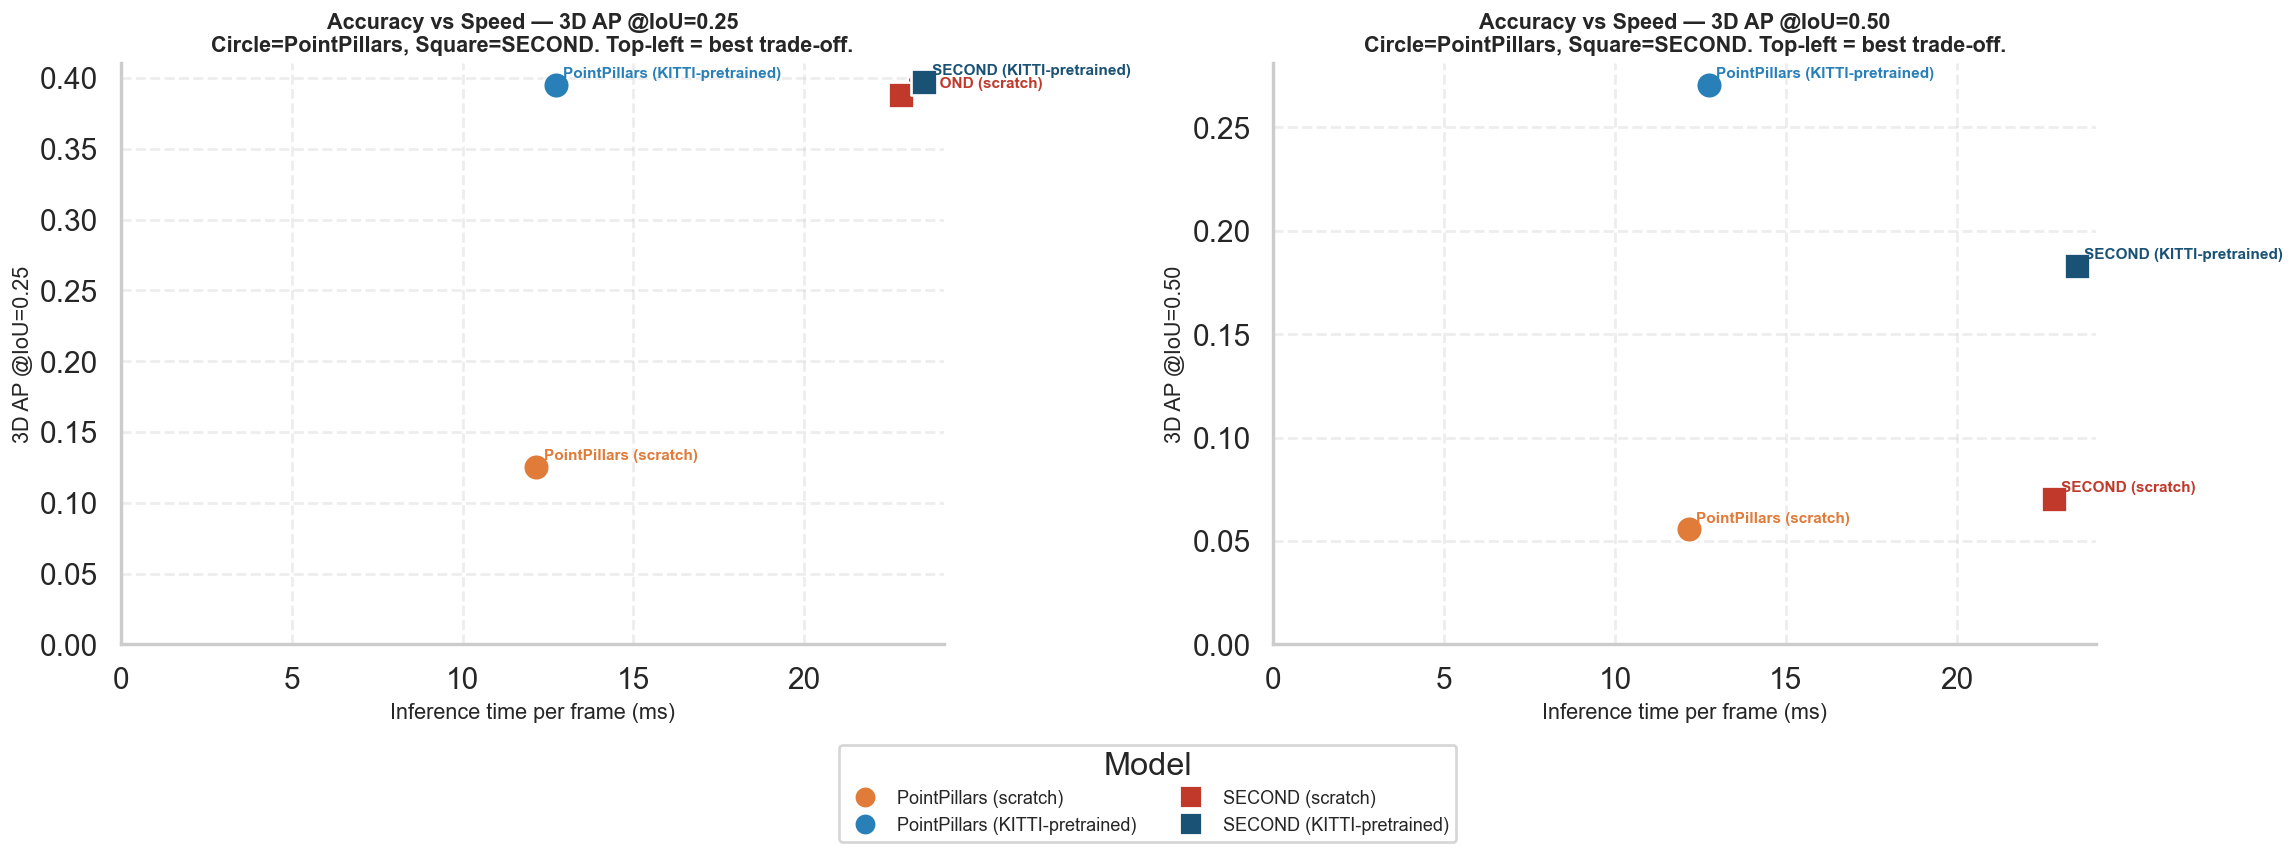

In [9]:
# ── Figure 4: Accuracy–speed scatter ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (ap_col, ap_label) in zip(axes, [
    ('3d_ap_0.25', '3D AP @IoU=0.25'),
    ('3d_ap_0.50', '3D AP @IoU=0.50'),
]):
    for _, row in aghri.iterrows():
        color  = MODEL_PALETTE.get(row['label'], '#AAB7B8')
        marker = 'o' if row['arch'] == 'PointPillars' else 's'
        ax.scatter(row['inf_time_per_frame_ms'], row[ap_col],
                   c=color, marker=marker, s=220, zorder=3,
                   edgecolors='white', linewidth=1.5)
        ax.annotate(row['label'],
                    xy=(row['inf_time_per_frame_ms'], row[ap_col]),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=8.5, color=color, fontweight='bold')

    ax.set_xlabel('Inference time per frame (ms)', fontsize=12)
    ax.set_ylabel(ap_label, fontsize=12)
    ax.set_title(f'Accuracy vs Speed — {ap_label}\n'
                 'Circle=PointPillars, Square=SECOND. Top-left = best trade-off.',
                 fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

legend_elems = [
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#E07B39',markersize=12,label='PointPillars (scratch)'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#2980B9',markersize=12,label='PointPillars (KITTI-pretrained)'),
    Line2D([0],[0],marker='s',color='w',markerfacecolor='#C0392B',markersize=12,label='SECOND (scratch)'),
    Line2D([0],[0],marker='s',color='w',markerfacecolor='#1A5276',markersize=12,label='SECOND (KITTI-pretrained)'),
]
fig.legend(handles=legend_elems, title='Model', loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.12), fontsize=10, frameon=True)
plt.tight_layout()
plt.show()

---
## Section 6 — Detailed Metrics: Precision, Recall, F1
> *Per-model breakdown at the two primary IoU thresholds.*

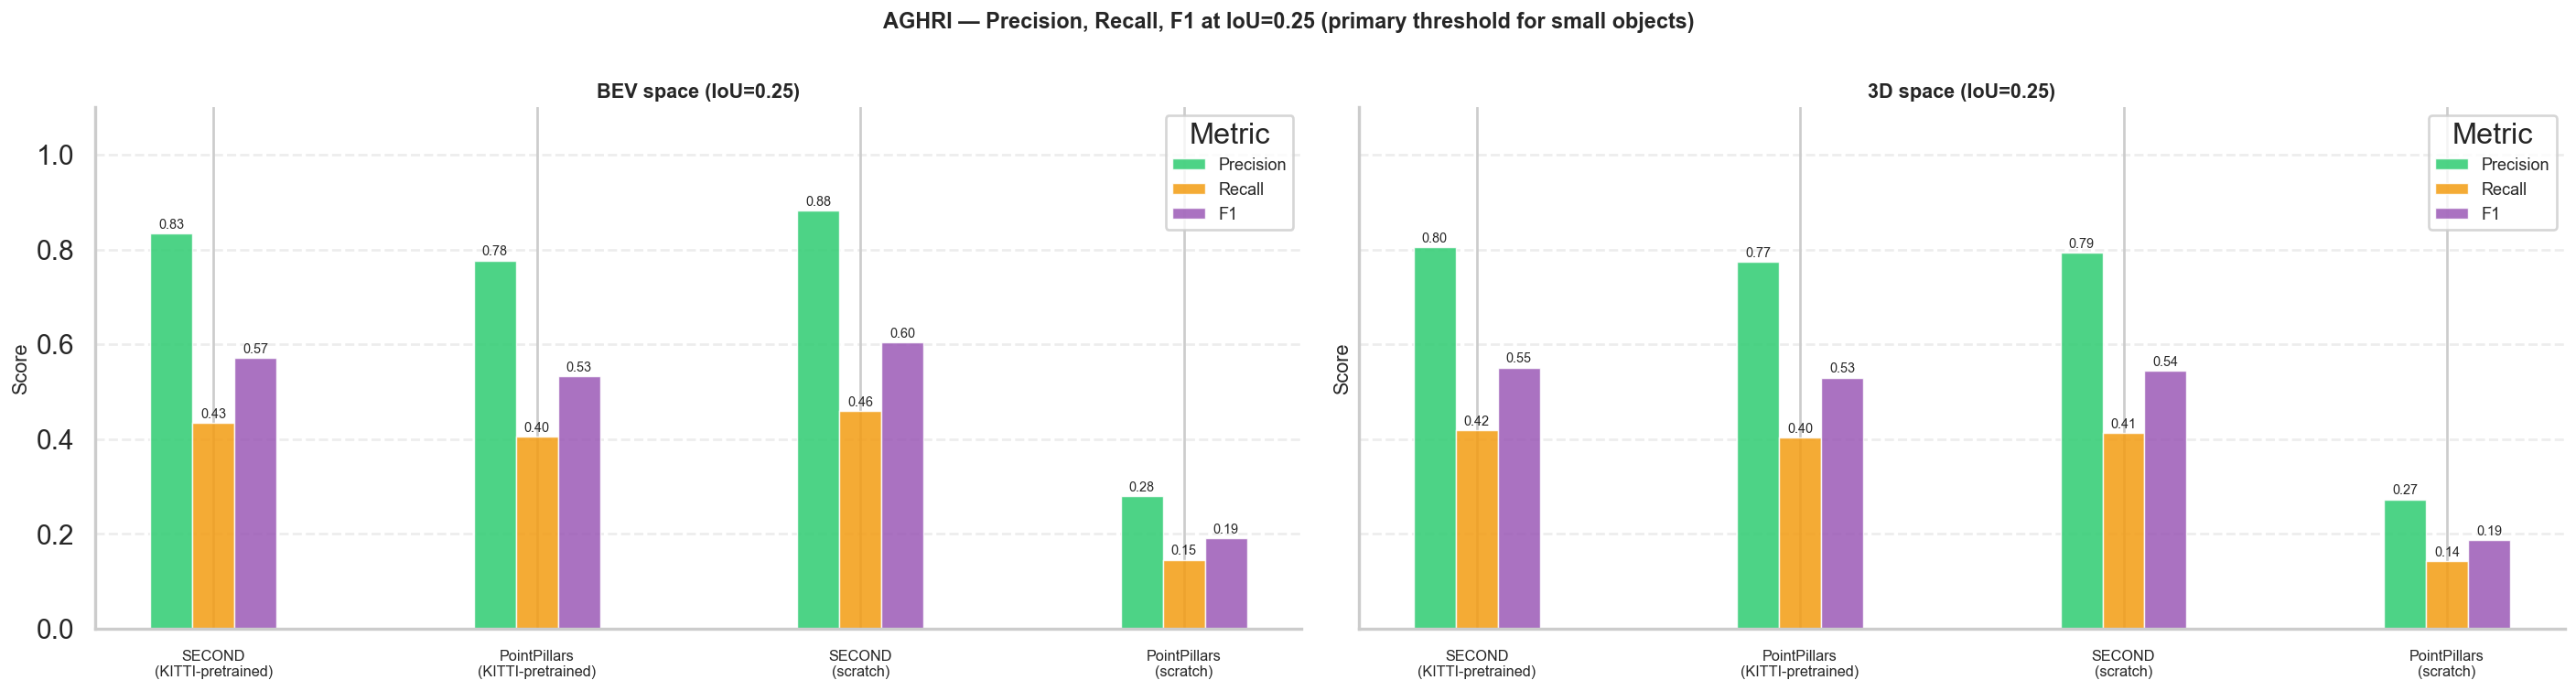

In [10]:
# ── Figure 5: Precision / Recall / F1 grouped bar ─────────────────────────────
PRF_METRICS = [
    ('bev_precision_0.25', '3d_precision_0.25', 'Precision'),
    ('bev_recall_0.25',    '3d_recall_0.25',    'Recall'),
    ('bev_f1_0.25',        '3d_f1_0.25',        'F1'),
]

x = np.arange(len(MODEL_ORDER))
width = 0.13

fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharey=True)

for ax_idx, (space, title) in enumerate([('bev', 'BEV space (IoU=0.25)'), ('3d', '3D space (IoU=0.25)')]):
    ax = axes[ax_idx]
    metric_set = [
        (f'{space}_precision_0.25', 'Precision', '#2ECC71'),
        (f'{space}_recall_0.25',    'Recall',    '#F39C12'),
        (f'{space}_f1_0.25',        'F1',        '#9B59B6'),
    ]
    for m_idx, (col, metric_name, color) in enumerate(metric_set):
        vals = [float(aghri.set_index('label').reindex(MODEL_ORDER).loc[m, col])
                if m in aghri['label'].values else np.nan
                for m in MODEL_ORDER]
        offset = (m_idx - 1) * width
        bars = ax.bar(x + offset, vals, width, label=metric_name,
                      color=color, edgecolor='white', linewidth=0.8, alpha=0.85)
        for bar, val in zip(bars, vals):
            if np.isfinite(val) and val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [m.replace(' (', '\n(') for m in MODEL_ORDER],
        fontsize=9
    )
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(title='Metric', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

fig.suptitle('AGHRI — Precision, Recall, F1 at IoU=0.25 (primary threshold for small objects)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 7 — KITTI Reference Benchmarks
> *In-domain KITTI results (models trained and evaluated on KITTI val split).*
> *Shown as context only — no cross-dataset transfer analysis.*

KITTI uses the official **easy / moderate / hard** difficulty splits based on occlusion and
truncation. Where available, official KITTI AP metrics are reported alongside the custom AP.

### KITTI val-set results (in-domain reference)

,Model,Epochs,Split,BEV AP @0.25,3D AP @0.25,BEV AP @0.50,3D AP @0.50,ms / frame,KITTI 3D AP Easy,KITTI 3D AP Mod.,KITTI 3D AP Hard,KITTI BEV AP Easy,KITTI BEV AP Mod.,KITTI BEV AP Hard
0,PointPillars,160,val,0.205,0.205,0.110,0.073,16.1,0.090,0.088,0.076,0.115,0.126,0.114
1,SECOND,40,val,0.061,0.060,0.035,0.028,26.3,0.027,0.028,0.028,0.033,0.035,0.034


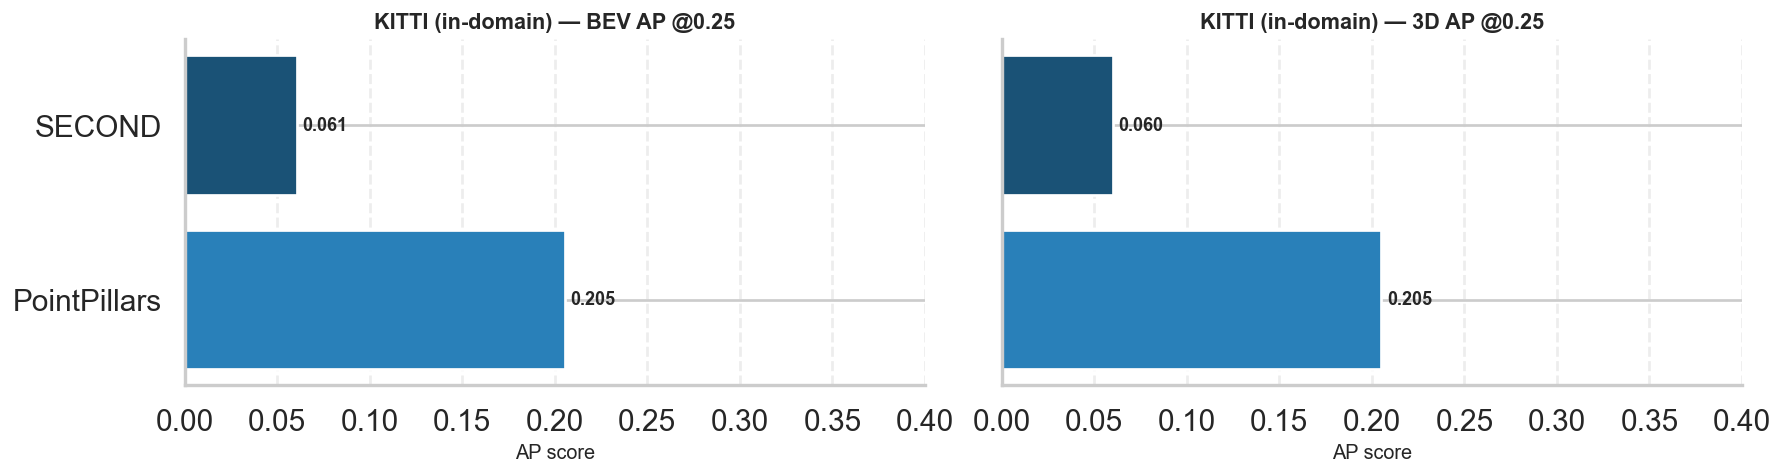

In [11]:
# ── KITTI reference table ──────────────────────────────────────────────────────
KITTI_COLS = [
    'label', 'epochs', 'eval_split',
    'bev_ap_0.25', '3d_ap_0.25', 'bev_ap_0.50', '3d_ap_0.50',
    'inf_time_per_frame_ms',
]
# Include official KITTI AP columns if present
kitti_official = [c for c in ['kitti_3d_ap_easy', 'kitti_3d_ap_moderate', 'kitti_3d_ap_hard',
                               'kitti_bev_ap_easy', 'kitti_bev_ap_moderate', 'kitti_bev_ap_hard']
                  if c in kitti.columns and kitti[c].notna().any()]

kitti_existing = [c for c in KITTI_COLS + kitti_official if c in kitti.columns]
kitti_tbl = (
    kitti[kitti_existing]
    .rename(columns={
        'label':                   'Model',
        'epochs':                  'Epochs',
        'eval_split':              'Split',
        'bev_ap_0.25':             'BEV AP @0.25',
        '3d_ap_0.25':              '3D AP @0.25',
        'bev_ap_0.50':             'BEV AP @0.50',
        '3d_ap_0.50':              '3D AP @0.50',
        'inf_time_per_frame_ms':   'ms / frame',
        'kitti_3d_ap_easy':        'KITTI 3D AP Easy',
        'kitti_3d_ap_moderate':    'KITTI 3D AP Mod.',
        'kitti_3d_ap_hard':        'KITTI 3D AP Hard',
        'kitti_bev_ap_easy':       'KITTI BEV AP Easy',
        'kitti_bev_ap_moderate':   'KITTI BEV AP Mod.',
        'kitti_bev_ap_hard':       'KITTI BEV AP Hard',
    })
    .sort_values('3D AP @0.25', ascending=False)
    .reset_index(drop=True)
)

kitti_fmt = {c: '{:.3f}' for c in kitti_tbl.columns if kitti_tbl[c].dtype == float}
kitti_fmt['ms / frame'] = '{:.1f}'
kitti_fmt['Epochs'] = '{:.0f}'

display(Markdown("### KITTI val-set results (in-domain reference)"))
display(
    kitti_tbl.style
    .format(kitti_fmt, na_rep='—')
    .set_caption('KITTI person class; eval_split = val. '
                 'Official KITTI AP uses different 11-point interpolation than custom AP.')
)

# ── Figure 6: KITTI BEV and 3D AP bar ────────────────────────────────────────
kitti_arch_palette = {
    'PointPillars': '#2980B9',
    'SECOND':       '#1A5276',
}
kitti_order = kitti.sort_values('3d_ap_0.25', ascending=False)['label'].tolist()
kitti_colors = [kitti_arch_palette.get(r['arch'], '#AAB7B8')
                for _, r in kitti.set_index('label').reindex(kitti_order).iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (col, title) in zip(axes, [
    ('bev_ap_0.25', 'BEV AP @0.25'),
    ('3d_ap_0.25',  '3D AP @0.25'),
]):
    vals = kitti.set_index('label').reindex(kitti_order)[col].values
    bars = ax.barh(kitti_order, vals, color=kitti_colors, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
    ax.set_xlabel('AP score', fontsize=11)
    ax.set_xlim(0, 0.4)
    ax.set_title(f'KITTI (in-domain) — {title}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

---
## Section 8 — Key Insights

In [12]:
# ── Auto-generated insight bullets ────────────────────────────────────────────
def get(model_label: str, col: str) -> float:
    row = aghri[aghri['label'] == model_label]
    return float(row[col].values[0]) if not row.empty and col in row.columns else float('nan')


pp_sc_3d25  = get('PointPillars (scratch)',          '3d_ap_0.25')
pp_pt_3d25  = get('PointPillars (KITTI-pretrained)', '3d_ap_0.25')
sec_sc_3d25 = get('SECOND (scratch)',                '3d_ap_0.25')
sec_pt_3d25 = get('SECOND (KITTI-pretrained)',       '3d_ap_0.25')

pp_sc_3d50  = get('PointPillars (scratch)',          '3d_ap_0.50')
pp_pt_3d50  = get('PointPillars (KITTI-pretrained)', '3d_ap_0.50')
sec_sc_3d50 = get('SECOND (scratch)',                '3d_ap_0.50')
sec_pt_3d50 = get('SECOND (KITTI-pretrained)',       '3d_ap_0.50')

pp_sc_ms  = get('PointPillars (scratch)',          'inf_time_per_frame_ms')
pp_pt_ms  = get('PointPillars (KITTI-pretrained)', 'inf_time_per_frame_ms')
sec_sc_ms = get('SECOND (scratch)',                'inf_time_per_frame_ms')
sec_pt_ms = get('SECOND (KITTI-pretrained)',       'inf_time_per_frame_ms')

# Best overall on AGHRI
best_row = aghri.loc[aghri['3d_ap_0.25'].idxmax()]
best_label = best_row['label']
best_3d25  = best_row['3d_ap_0.25']
best_3d50  = best_row['3d_ap_0.50']
best_ms    = best_row['inf_time_per_frame_ms']

lines = [
    f"**Best AGHRI model overall: {best_label}** — "
    f"3D AP @0.25 = **{best_3d25:.3f}**, 3D AP @0.50 = **{best_3d50:.3f}**, "
    f"{best_ms:.1f} ms/frame.",

    f"**KITTI pretraining strongly benefits PointPillars on AGHRI**: "
    f"3D AP @0.25 rises from {pp_sc_3d25:.3f} (scratch) to {pp_pt_3d25:.3f} (KITTI-pretrained) "
    f"(Δ = +{pp_pt_3d25 - pp_sc_3d25:.3f}). At IoU=0.50, the gain is even larger: "
    f"{pp_sc_3d50:.3f} → {pp_pt_3d50:.3f} (Δ = +{pp_pt_3d50 - pp_sc_3d50:.3f}).",

    f"**SECOND scratch is competitive without pretraining**: "
    f"3D AP @0.25 = {sec_sc_3d25:.3f} vs {sec_pt_3d25:.3f} (KITTI-pretrained, Δ = {sec_pt_3d25 - sec_sc_3d25:+.3f}). "
    f"However, pretraining still helps considerably at IoU=0.50: "
    f"{sec_sc_3d50:.3f} → {sec_pt_3d50:.3f} (Δ = +{sec_pt_3d50 - sec_sc_3d50:.3f}).",

    f"**PointPillars is ~{sec_sc_ms / pp_sc_ms:.1f}× faster than SECOND**: "
    f"PointPillars scratch = {pp_sc_ms:.1f} ms ({1000/pp_sc_ms:.0f} FPS), "
    f"SECOND scratch = {sec_sc_ms:.1f} ms ({1000/sec_sc_ms:.0f} FPS). "
    f"Both exceed 30 FPS (real-time threshold at 33.3 ms), making them viable for deployment.",

    f"**IoU threshold matters for small objects**: all models show a large gap between "
    f"AP @0.25 and AP @0.50. For the best model, 3D AP @0.25 = {best_3d25:.3f} vs "
    f"AP @0.50 = {best_3d50:.3f} — a {(best_3d25 - best_3d50) / best_3d25 * 100:.0f}% drop, "
    f"confirming that tight 3D bounding-box localisation of pedestrians remains challenging.",
]

display(Markdown("### Key Insights\n\n" + "\n\n".join(f"- {l}" for l in lines)))

### Key Insights

- **Best AGHRI model overall: SECOND (KITTI-pretrained)** — 3D AP @0.25 = **0.397**, 3D AP @0.50 = **0.183**, 23.5 ms/frame.

- **KITTI pretraining strongly benefits PointPillars on AGHRI**: 3D AP @0.25 rises from 0.125 (scratch) to 0.395 (KITTI-pretrained) (Δ = +0.270). At IoU=0.50, the gain is even larger: 0.056 → 0.270 (Δ = +0.215).

- **SECOND scratch is competitive without pretraining**: 3D AP @0.25 = 0.388 vs 0.397 (KITTI-pretrained, Δ = +0.009). However, pretraining still helps considerably at IoU=0.50: 0.070 → 0.183 (Δ = +0.113).

- **PointPillars is ~1.9× faster than SECOND**: PointPillars scratch = 12.2 ms (82 FPS), SECOND scratch = 22.8 ms (44 FPS). Both exceed 30 FPS (real-time threshold at 33.3 ms), making them viable for deployment.

- **IoU threshold matters for small objects**: all models show a large gap between AP @0.25 and AP @0.50. For the best model, 3D AP @0.25 = 0.397 vs AP @0.50 = 0.183 — a 54% drop, confirming that tight 3D bounding-box localisation of pedestrians remains challenging.

---
## Section 9 — Key Numbers for Paper

In [13]:
# ── Printable key numbers ─────────────────────────────────────────────────────
print("=" * 72)
print("  3D DETECTION — KEY NUMBERS FOR PAPER")
print("=" * 72)

print("\n── AGHRI test set — all models ────────────────────────────────────────")
print(f"{'Model':<38} {'BEV@0.25':>8} {'3D@0.25':>8} {'BEV@0.50':>8} {'3D@0.50':>8} {'ms/f':>6}")
print("-" * 80)
for m in MODEL_ORDER:
    row = aghri[aghri['label'] == m]
    if row.empty:
        continue
    r = row.iloc[0]
    print(f"{m:<38} "
          f"{r['bev_ap_0.25']:>8.3f} {r['3d_ap_0.25']:>8.3f} "
          f"{r['bev_ap_0.50']:>8.3f} {r['3d_ap_0.50']:>8.3f} "
          f"{r['inf_time_per_frame_ms']:>6.1f}")

print("\n── Pretraining gains (KITTI-pretrained − scratch) ──────────────────────")
for arch in ['PointPillars', 'SECOND']:
    sub = aghri[aghri['arch'] == arch].set_index('regime')
    if 'Scratch' not in sub.index or 'KITTI-pretrained' not in sub.index:
        continue
    for col, label in [('3d_ap_0.25','3D AP@0.25'), ('3d_ap_0.50','3D AP@0.50')]:
        sc = float(sub.loc['Scratch',          col])
        pt = float(sub.loc['KITTI-pretrained', col])
        print(f"  {arch:<15} {label:<12} scratch={sc:.3f}  pretrained={pt:.3f}  Δ={pt-sc:+.3f}")

print("\n── KITTI val set (reference) ───────────────────────────────────────────")
print(f"{'Model':<20} {'BEV@0.25':>8} {'3D@0.25':>8} {'BEV@0.50':>8} {'3D@0.50':>8} {'ms/f':>6}")
print("-" * 65)
for _, r in kitti.iterrows():
    print(f"{r['label']:<20} "
          f"{r['bev_ap_0.25']:>8.3f} {r['3d_ap_0.25']:>8.3f} "
          f"{r['bev_ap_0.50']:>8.3f} {r['3d_ap_0.50']:>8.3f} "
          f"{r['inf_time_per_frame_ms']:>6.1f}")

print("\n── Inference speed summary ─────────────────────────────────────────────")
for _, r in aghri.iterrows():
    fps = 1000 / r['inf_time_per_frame_ms']
    print(f"  {r['label']:<38}  {r['inf_time_per_frame_ms']:.1f} ms  ({fps:.0f} FPS)")

  3D DETECTION — KEY NUMBERS FOR PAPER

── AGHRI test set — all models ────────────────────────────────────────
Model                                  BEV@0.25  3D@0.25 BEV@0.50  3D@0.50   ms/f
--------------------------------------------------------------------------------
SECOND (KITTI-pretrained)                 0.416    0.397    0.272    0.183   23.5
PointPillars (KITTI-pretrained)           0.397    0.395    0.347    0.270   12.7
SECOND (scratch)                          0.446    0.388    0.161    0.070   22.8
PointPillars (scratch)                    0.127    0.125    0.095    0.056   12.2

── Pretraining gains (KITTI-pretrained − scratch) ──────────────────────
  PointPillars    3D AP@0.25   scratch=0.125  pretrained=0.395  Δ=+0.270
  PointPillars    3D AP@0.50   scratch=0.056  pretrained=0.270  Δ=+0.215
  SECOND          3D AP@0.25   scratch=0.388  pretrained=0.397  Δ=+0.009
  SECOND          3D AP@0.50   scratch=0.070  pretrained=0.183  Δ=+0.113

── KITTI val set (reference) ─